In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT


🔹 Class: AnnualCrop


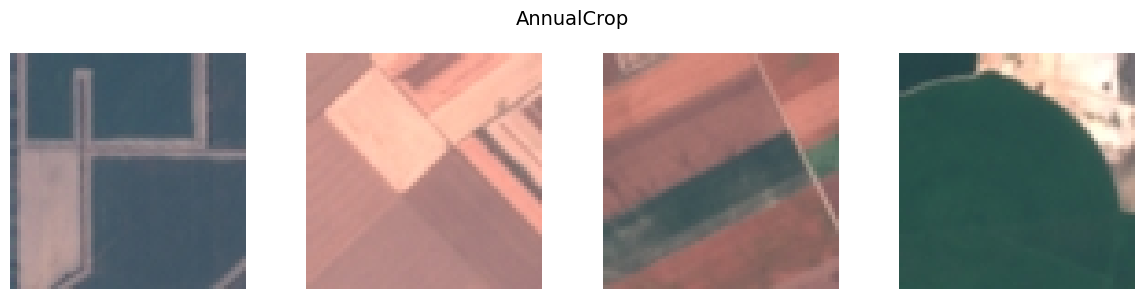

🔹 Class: Forest


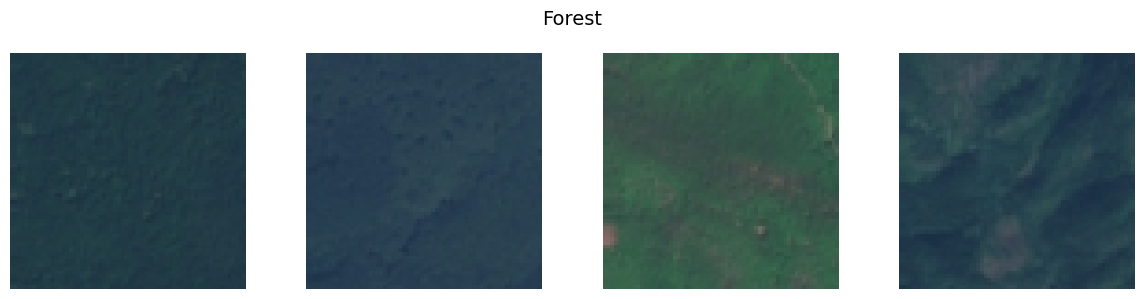

🔹 Class: HerbaceousVegetation


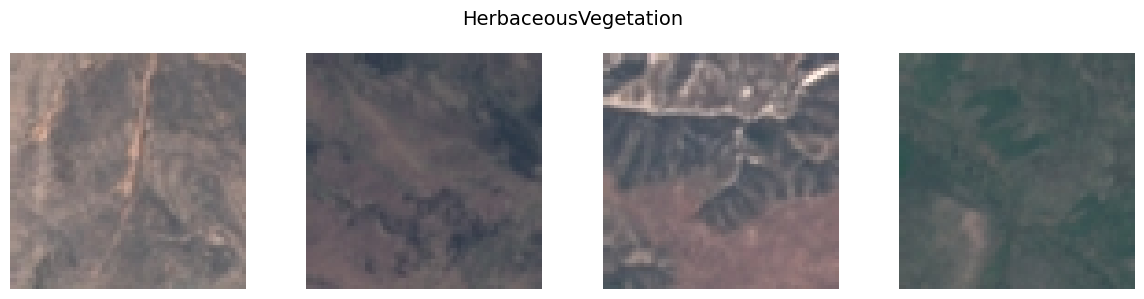

🔹 Class: Highway


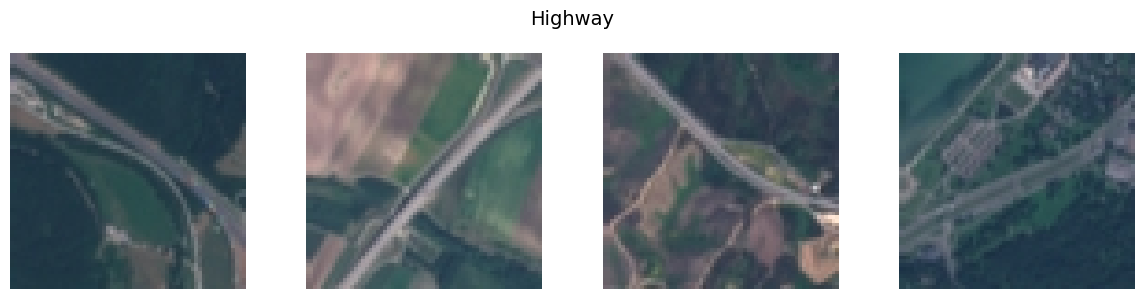

🔹 Class: Industrial


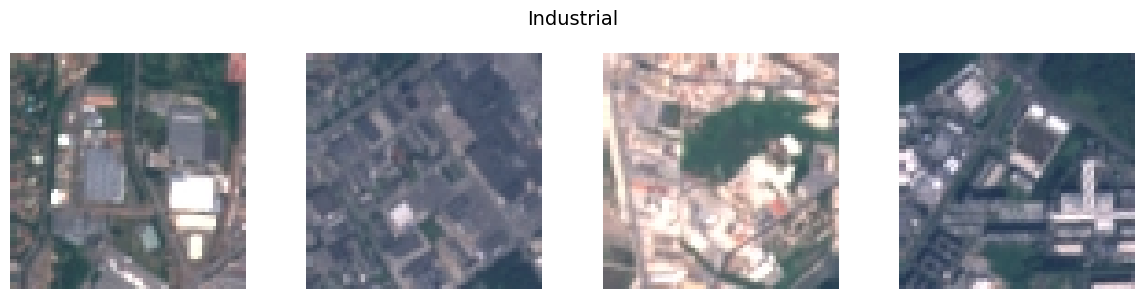

🔹 Class: Pasture


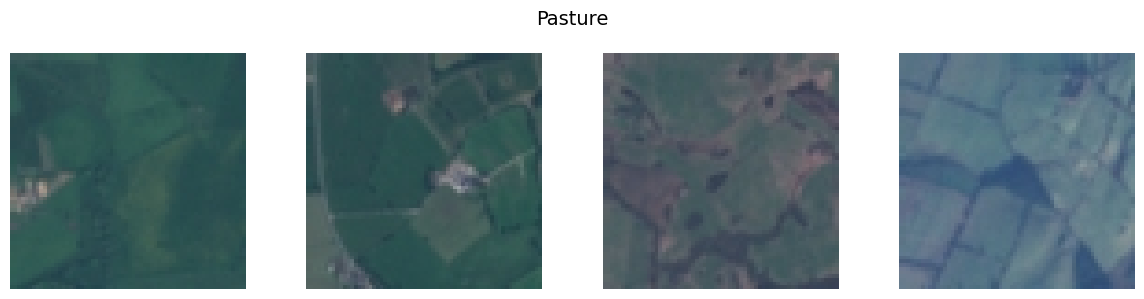

🔹 Class: PermanentCrop


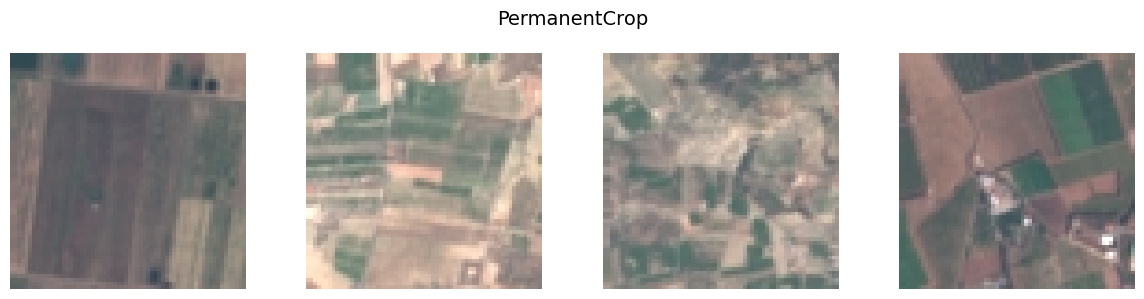

🔹 Class: Residential


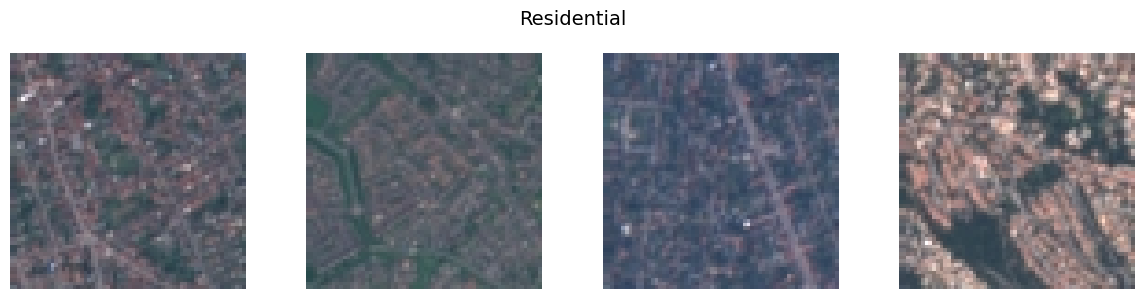

🔹 Class: River


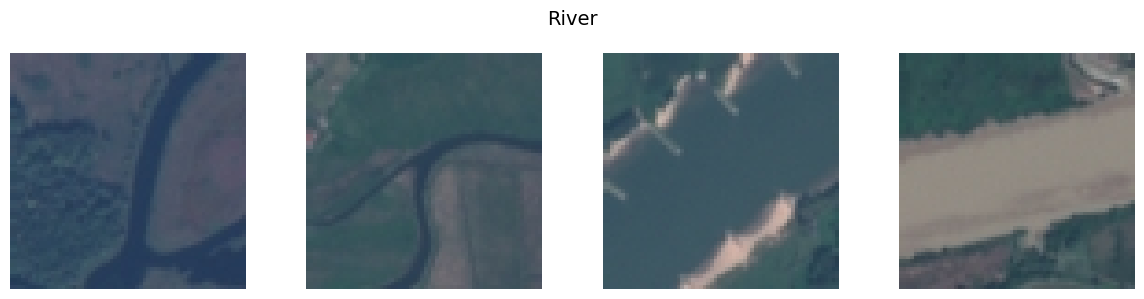

🔹 Class: SeaLake


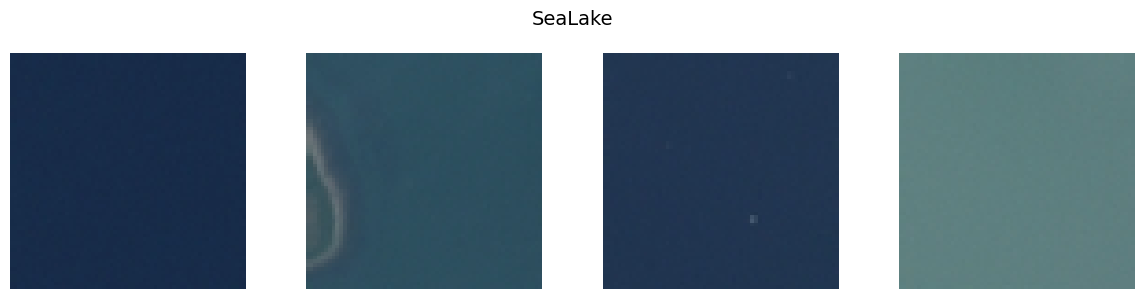

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path to EuroSAT dataset
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Get class names (folder names)
class_names = sorted([d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))])

# Display 4 images from each class
for class_name in class_names:
    class_path = os.path.join(source_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))][:4]  # Get first 4 images

    print(f"🔹 Class: {class_name}")

    # Set up subplot grid
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    fig.suptitle(class_name, fontsize=14)

    for i, img_file in enumerate(image_files):
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


In [5]:
import os
import random
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import matplotlib.pyplot as plt


In [6]:
# Original EuroSAT dataset path
original_data_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Where to save the split dataset
base_split_dir = "/content/EuroSAT_split"

# Create split folders if they don't exist
split_dirs = ['train', 'val', 'test']
for split in split_dirs:
    os.makedirs(os.path.join(base_split_dir, split), exist_ok=True)


In [8]:
import os
import random
import shutil

# EuroSAT original dataset path (each class in its folder)
original_data_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Folder to store split dataset
base_split_dir = "/content/EuroSAT_50_split"

# Define folders for split
split_dirs = ['train', 'val', 'test']
for split in split_dirs:
    os.makedirs(os.path.join(base_split_dir, split), exist_ok=True)


In [9]:
split_ratio = (0.7, 0.15, 0.15)  # 70% train, 15% val, 15% test
max_images_per_class = 50

# Only run if not already split
already_split = all(
    os.path.exists(os.path.join(base_split_dir, split, class_name))
    for split in split_dirs
    for class_name in os.listdir(original_data_dir)
    if os.path.isdir(os.path.join(original_data_dir, class_name))
)

if not already_split:
    print("📂 Splitting 50 images per class into train, val, test...")

    class_names = os.listdir(original_data_dir)
    for class_name in class_names:
        class_dir = os.path.join(original_data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        images = sorted(os.listdir(class_dir))
        images = [img for img in images if img.endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(images)
        images = images[:max_images_per_class]  # take only first 50

        n_total = len(images)
        n_train = int(n_total * split_ratio[0])
        n_val = int(n_total * split_ratio[1])

        split_paths = {
            'train': images[:n_train],
            'val': images[n_train:n_train + n_val],
            'test': images[n_train + n_val:]
        }

        for split in split_dirs:
            split_class_dir = os.path.join(base_split_dir, split, class_name)
            os.makedirs(split_class_dir, exist_ok=True)
            for img_name in split_paths[split]:
                src_path = os.path.join(class_dir, img_name)
                dst_path = os.path.join(split_class_dir, img_name)
                shutil.copy(src_path, dst_path)

    print("✅ Splitting completed.")
else:
    print("✅ Already split. Skipping...")


📂 Splitting 50 images per class into train, val, test...
✅ Splitting completed.


In [10]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_split_dir, "train"),
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_split_dir, "val"),
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_split_dir, "test"),
    image_size=img_size,
    batch_size=batch_size
)


Found 350 files belonging to 10 classes.
Found 70 files belonging to 10 classes.
Found 80 files belonging to 10 classes.


In [22]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
import matplotlib.pyplot as plt


In [23]:
# Path to 3-way split dataset
base_dir = "/content/EuroSAT_50_split"  # Change to your dataset path

# Image size required for EfficientNetB0
img_size = (224, 224)
batch_size = 16

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, 'train'),
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, 'val'),
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, 'test'),
    image_size=img_size,
    batch_size=batch_size
)


Found 350 files belonging to 10 classes.
Found 70 files belonging to 10 classes.
Found 80 files belonging to 10 classes.


In [24]:
AUTOTUNE = tf.data.AUTOTUNE

# Apply EfficientNet preprocessing (rescales to [-1, 1])
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)


In [25]:
num_classes = 10  # EuroSAT has 10 land cover classes

# Load base EfficientNetB0
base_model = EfficientNetB0(
    input_shape=img_size + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base model initially

# Build classification model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.2104 - loss: 2.2518 - val_accuracy: 0.6857 - val_loss: 1.4976
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6551 - loss: 1.3669 - val_accuracy: 0.7571 - val_loss: 1.0960
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7770 - loss: 0.9639 - val_accuracy: 0.8429 - val_loss: 0.8927
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8343 - loss: 0.7338 - val_accuracy: 0.8571 - val_loss: 0.7820
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8745 - loss: 0.6234 - val_accuracy: 0.8429 - val_loss: 0.7111
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9026 - loss: 0.5538 - val_accuracy: 0.8571 - val_loss: 0.6672
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9396 - loss: 0.4105 - val_accuracy: 0.8286 - val_loss: 0.6443
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9394 - loss: 0.3838 - val_accuracy: 0.8000 - val_loss:

In [35]:
# Get best (maximum) training and validation accuracy
best_train_acc = max(history.history['accuracy'])
best_val_acc = max(history.history['val_accuracy'])

# Print nicely formatted best accuracies
print(f"🏆 Best Training Accuracy: {best_train_acc * 100:.2f}%")
print(f"🌟 Best Validation Accuracy: {best_val_acc * 100:.2f}%")


🏆 Best Training Accuracy: 94.86%
🌟 Best Validation Accuracy: 85.71%


In [29]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_ds)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 933ms/step - accuracy: 0.8349 - loss: 0.5444


In [30]:
print(f"🧪 Final Test Accuracy: {test_acc * 100:.2f}%")


🧪 Final Test Accuracy: 82.50%


In [33]:
!pip install ultralytics


In [34]:
from ultralytics import YOLO

# Load YOLOv8 classification model
model = YOLO('yolov8n-cls.pt')

# Train on your EuroSAT split
model.train(
    data='/content/EuroSAT_50_split',
    epochs=10,
    imgsz=224,
    project='runs/classify',
    name='eurosat_yolo_cls',
    pretrained=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.31M/5.31M [00:00<00:00, 67.7MB/s]


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_50_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=eurosat_yolo_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

train: Scanning /content/EuroSAT_50_split/train... 350 images, 0 corrupt: 100%|██████████| 350/350 [00:00<00:00, 6505.53it/s]

train: New cache created: /content/EuroSAT_50_split/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 107.4±35.3 MB/s, size: 3.2 KB)


...

                   all      0.786          1

10 epochs completed in 0.058 hours.


Optimizer stripped from runs/classify/eurosat_yolo_cls/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/eurosat_yolo_cls/weights/best.pt, 3.0MB

Validating runs/classify/eurosat_yolo_cls/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/EuroSAT_50_split/train... found 350 images in 10 classes ✅ 
val: /content/EuroSAT_50_split/val... found 70 images in 10 classes ✅ 
test: /content/EuroSAT_50_split/test... found 80 images in 10 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 3/3 [00:01<00:00,  2.40it/s]


                   all        0.8          1
Speed: 0.0ms preprocess, 14.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/eurosat_yolo_cls


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78d7e50de410>
curves: []
curves_results: []
fitness: 0.9000000059604645
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.800000011920929, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9000000059604645}
save_dir: PosixPath('runs/classify/eurosat_yolo_cls')
speed: {'preprocess': 0.0008103571287522625, 'inference': 14.07657560001618, 'loss': 5.48142842100268e-05, 'postprocess': 0.00018024286743769023}
task: 'classify'
top1: 0.800000011920929
top5: 1.0